In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("el_nino.csv")
# Dropping Humidity
df_nohum = df.drop(columns= ["humidity"])
df_nohum.dropna(inplace=True)
df_nohum

,year,month,day,date,latitude,longitude,zon_winds,mer_winds,air_temp,ss_temp
0,80,3,7,800307,-0.02,-109.46,-6.8,0.7,26.14,26.24
1,80,3,8,800308,-0.02,-109.46,-4.9,1.1,25.66,25.97
2,80,3,9,800309,-0.02,-109.46,-4.5,2.2,25.69,25.28
3,80,3,10,800310,-0.02,-109.46,-3.8,1.9,25.57,24.31
4,80,3,11,800311,-0.02,-109.46,-4.2,1.5,25.30,23.19
...,...,...,...,...,...,...,...,...,...,...
178074,98,6,10,980610,8.95,-140.33,-6.8,-5.3,27.52,28.17
178075,98,6,11,980611,8.96,-140.33,-5.1,-0.4,26.04,28.14
178076,98,6,12,980612,8.96,-140.32,-4.3,-3.3,25.80,27.87
178077,98,6,13,980613,8.95,-140.34,-6.1,-4.8,27.17,27.93


In [3]:
east_hem = df_nohum[(df_nohum["longitude"] > -50 )]
east_hem.drop(["longitude", "latitude"], axis=1, inplace=True)
east_hem_grouped = east_hem.groupby(["year", "month", "day", "date"]).mean()
east_hem_grouped.reset_index(inplace=True)
east_hem_grouped["date"] = pd.to_datetime(east_hem_grouped["date"].astype(str), format="%y%m%d")

west_hem = df_nohum[(df_nohum["longitude"] <= -50 )]
west_hem.drop(["longitude", "latitude"], axis=1, inplace=True)

west_hem_grouped = west_hem.groupby(["year", "month", "day", "date"]).mean()

west_hem_grouped.reset_index(inplace=True)

west_hem_grouped["date"] = pd.to_datetime(west_hem_grouped["date"].astype(str), format="%y%m%d")

In [4]:
# Point Settings
alpha = 1
size = 0.6

# El Nino Chart Settings
elnino = [
          "1987-01-01",
          "1991-01-01",
          "1991-06-01",
          "1993-01-01", 
          "1994-01-01",  
          "1997-01-01", 
        ]

def plot_vertical_lines():
    for year in elnino:
        plt.axvline(pd.Timestamp(year), color="black", linestyle="--", alpha=0.4)


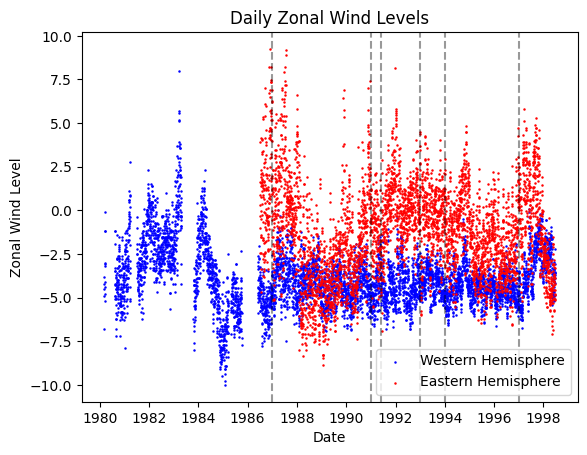

In [5]:
plt.scatter(west_hem_grouped["date"], west_hem_grouped["zon_winds"], label="Western Hemisphere", marker="o",alpha=alpha, s=size, color="blue")
plt.scatter(east_hem_grouped["date"], east_hem_grouped["zon_winds"], label="Eastern Hemisphere", marker="o",alpha=alpha, s=size, color="red")
plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Levels")
plt.legend()
plot_vertical_lines()

plt.show()


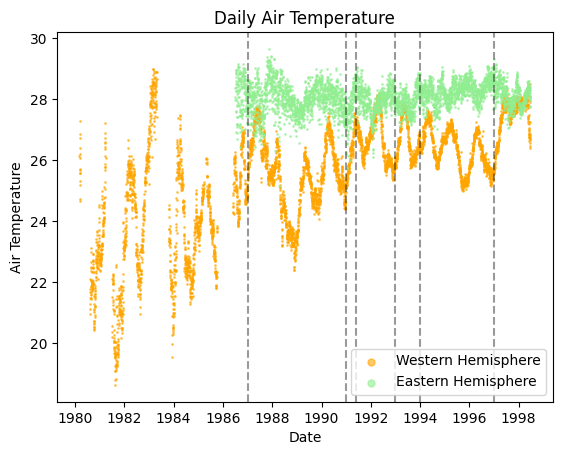

In [6]:
plt.scatter(west_hem_grouped["date"], west_hem_grouped["air_temp"], label="Western Hemisphere", marker="o",alpha=0.6, s=1, color="orange")
plt.scatter(east_hem_grouped["date"], east_hem_grouped["air_temp"], label="Eastern Hemisphere", marker="o",alpha=0.6, s=1, color="lightgreen")
plt.xlabel("Date")
plt.ylabel("Air Temperature")
plt.title("Daily Air Temperature")
plt.legend(markerscale=5)
plot_vertical_lines()

plt.show()